In [1]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

from geoai.utils_ds.preprocessing_ops import PreProcessingOperations
from geoai.utils_ds.visualize_ops import VisualizeOperations
from geoai.utils_ml.model_ops import ModelOperations

pre_ops = PreProcessingOperations()
vis_ops = VisualizeOperations()
model_ops = ModelOperations()

In [3]:
# Load data
X_train = pd.read_csv("csv_files/X_train_fe.csv")
X_test = pd.read_csv("csv_files/X_test_fe.csv")
y_train = pd.read_csv("csv_files/y_train_encoded.csv")
y_test = pd.read_csv("csv_files/y_test_encoded.csv")
X_train.head()

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,SWIR REI,NDVI^2,NDVI NDBI,NDVI REI,NDBI^2,NDBI REI,REI^2,NDVI_binary_non_veg,NDVI_binary_veg,NDVI_categorized_encoded
0,5.860786,6.297109,5.780744,8.094989,7.588999,0.599142,-0.284788,0.002541,34.348815,36.906012,...,0.019287,0.358971,-0.170628,0.001523,0.081104,-0.000724,6.459135e-06,0,1,2
1,5.968708,6.320768,5.942799,8.012239,7.596894,0.574505,-0.229186,0.002224,35.625470,37.726818,...,0.016899,0.330056,-0.131668,0.001278,0.052526,-0.000510,4.948067e-06,0,1,2
2,7.071573,7.111240,7.145984,7.234177,7.431537,0.043156,0.093877,0.000127,50.007150,50.287656,...,0.000947,0.001862,0.004051,0.000006,0.008813,0.000012,1.625104e-08,1,0,0
3,5.897703,6.305362,5.981414,8.085025,7.627057,0.578262,-0.255084,0.002435,34.782903,37.187156,...,0.018575,0.334387,-0.147505,0.001408,0.065068,-0.000621,5.931214e-06,0,1,2
4,6.999970,7.010613,7.051856,7.113956,7.361375,0.030594,0.116155,0.000098,48.999577,49.074077,...,0.000724,0.000936,0.003554,0.000003,0.013492,0.000011,9.665850e-09,1,0,0


In [4]:
# scale the data
X_train_fe_scaled, X_test_fe_scaled = pre_ops.scale_to_minmax(X_train, X_test)
X_train_fe_scaled.head()

,BLUE,GREEN,RED,NIR,SWIR,NDVI,NDBI,REI,BLUE^2,BLUE GREEN,...,SWIR REI,NDVI^2,NDVI NDBI,NDVI REI,NDBI^2,NDBI REI,REI^2,NDVI_binary_non_veg,NDVI_binary_veg,NDVI_categorized_encoded
0,0.028792,0.092959,0.036666,0.811104,0.252389,0.998145,0.074872,0.958466,0.023717,0.048942,...,0.967258,0.996101,0.115180,0.975468,0.741622,0.087732,0.918597,0.0,1.0,1.0
1,0.070846,0.103193,0.096423,0.752344,0.257980,0.959140,0.165553,0.838990,0.058899,0.072450,...,0.847577,0.915867,0.281023,0.819191,0.480302,0.279052,0.703698,0.0,1.0,1.0
2,0.500597,0.445141,0.540090,0.199853,0.140895,0.117894,0.692431,0.048801,0.455225,0.432197,...,0.048329,0.005168,0.858749,0.006760,0.080586,0.745577,0.002311,1.0,0.0,0.0
3,0.043177,0.096529,0.110662,0.804029,0.279338,0.965088,0.123316,0.918495,0.035680,0.056994,...,0.931568,0.927885,0.213608,0.902424,0.594985,0.179424,0.843518,0.0,1.0,1.0
4,0.472696,0.401611,0.505381,0.114486,0.091216,0.098004,0.728764,0.037811,0.427459,0.397440,...,0.037124,0.002597,0.856630,0.005167,0.123372,0.745088,0.001375,1.0,0.0,0.0


d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


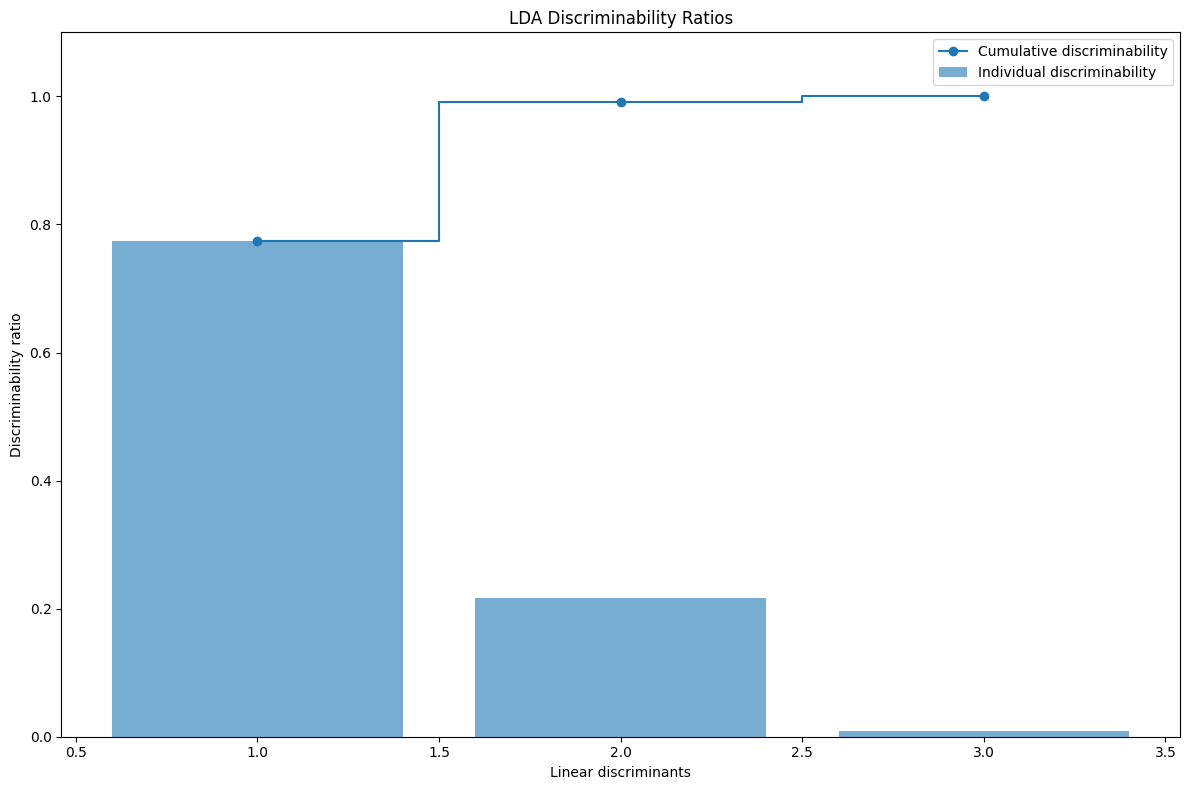

array([0.77465057, 0.99064333, 1.        ])

In [5]:
explained_variance_ratio, cumulative_discriminability = (
    pre_ops.compute_discriminability_ratios(X_train_fe_scaled, y_train)
)

vis_ops.plot_discriminality_ratio(
    explained_variance_ratio, cumulative_discriminability
)
cumulative_discriminability

In [5]:
# apply_lda using 3 components
X_train_lda, X_test_lda = pre_ops.apply_lda(
    X_train_fe_scaled, y_train, X_test_fe_scaled, n_components=3
)    

d:\Projects\GEOAI\GeoAI-ISPRS-SS\geoai-env\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [6]:
# fit the model using the pca data
lr = LogisticRegression(solver='lbfgs', max_iter=1000)
lr.fit(X_train_lda, y_train.values.ravel())

# predict the validation set
y_train_pred = lr.predict(X_train_lda)
y_pred_test = lr.predict(X_test_lda)

# calculate the accuracy
print(f"Train Accuracy: {model_ops.calculate_classification_accuracy(y_train, y_train_pred)}")
print(f"Test Accuracy: {model_ops.calculate_classification_accuracy(y_test, y_pred_test)}")

Train Accuracy: (0.937467700258398, 0.9378469707503807, 0.937467700258398, 0.9375970119680029)
Test Accuracy: (0.9256198347107438, 0.9263747494029527, 0.9256198347107438, 0.9258429757018053)


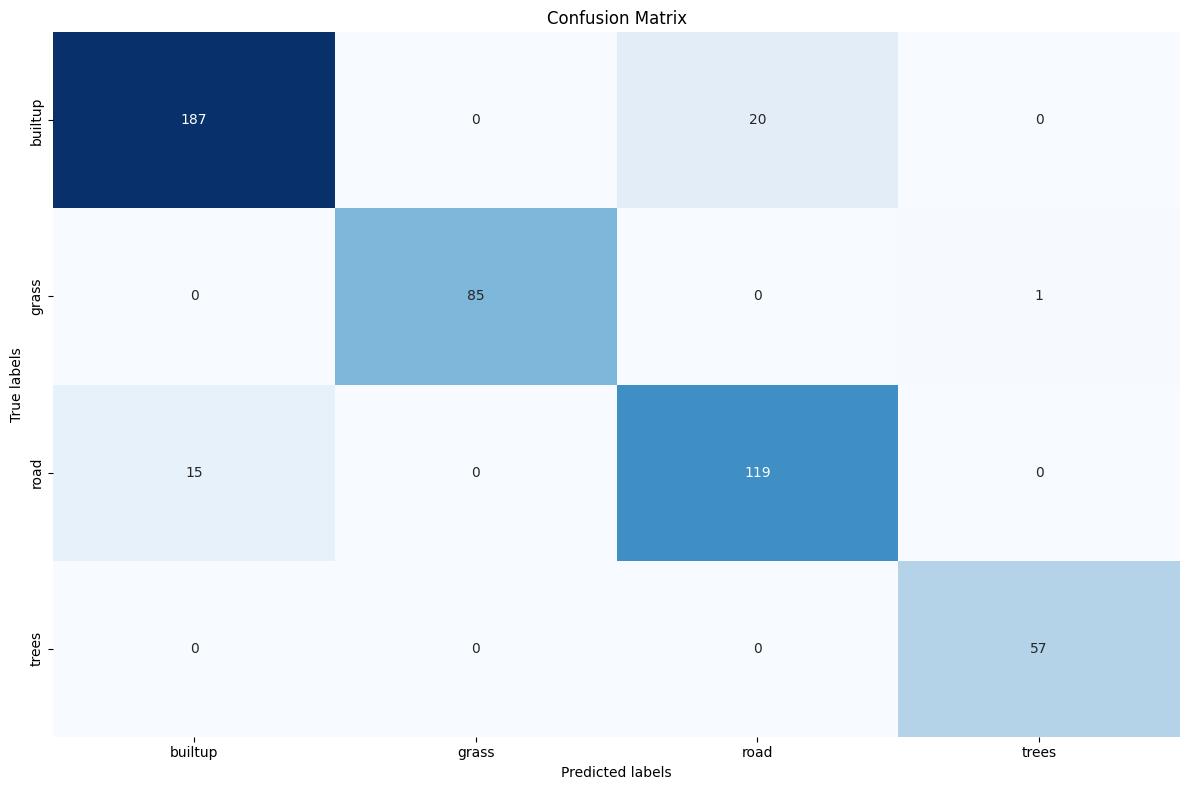

In [7]:
label_mapping = {0: 'builtup', 1: 'grass', 2: 'road', 3: 'trees'}
class_names_str = [label_mapping[label] for label in lr.classes_]
vis_ops.plot_confusion_matrix(y_test, y_pred_test, class_names_str)

END